In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

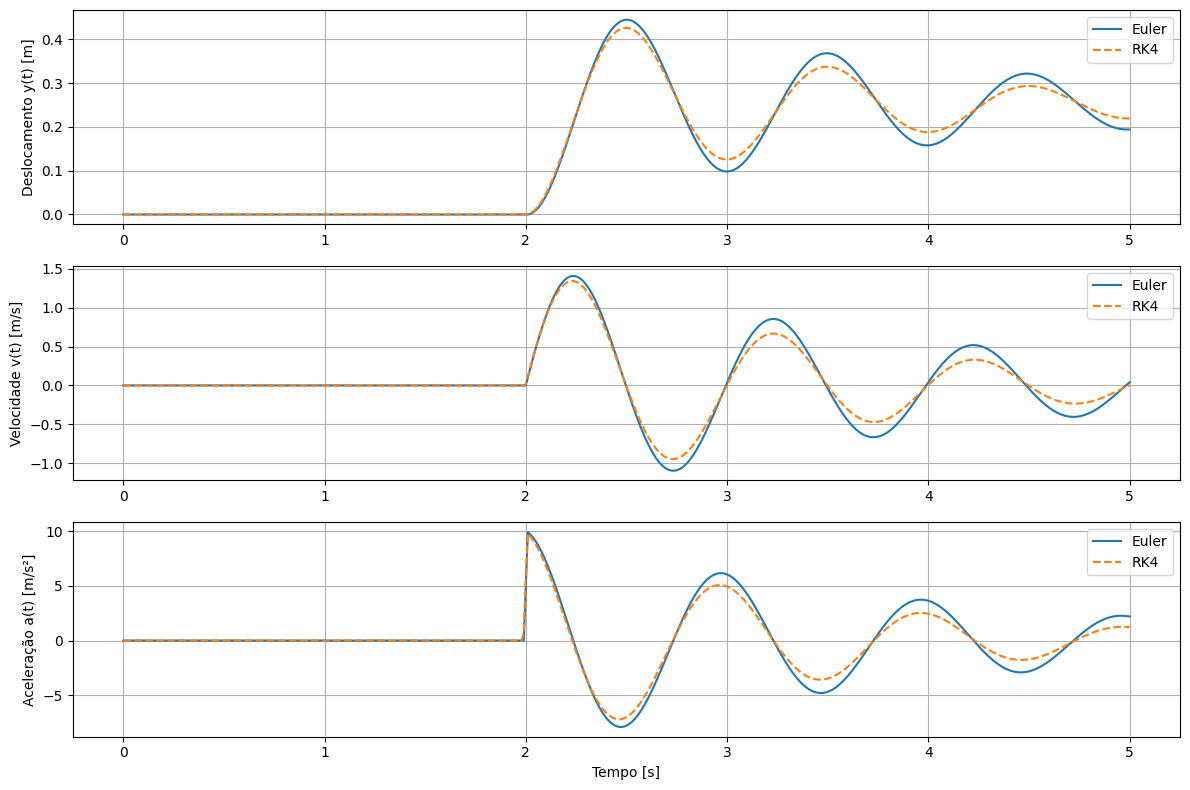

In [ ]:
# Parâmetros do problema
M = 500        # kg
Ky = 20000     # N/m
Cy = 700       # Ns/m

# Função z(t) e dz(t)/dt
def z(t):
    return 0 if t < 2 else 0.25

def dz(t):
    return 0  # degrau => derivada é zero exceto em t=2 (descontínuo)

# Sistema de equações (forma de 1ª ordem): dy/dt = v, dv/dt = ...
def f(t, Y):
    y, v = Y
    dydt = v
    dvdt = (-Ky * (y - z(t)) - Cy * (v - dz(t))) / M
    return np.array([dydt, dvdt])

# Método de Euler
def euler(f, Y0, t):
    h = t[1] - t[0]
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    for i in range(1, len(t)):
        Y[i] = Y[i-1] + h * f(t[i-1], Y[i-1])
    return Y

# Método de Runge-Kutta de 4ª ordem
def rk4(f, Y0, t):
    h = t[1] - t[0]
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    for i in range(1, len(t)):
        k1 = f(t[i-1], Y[i-1])
        k2 = f(t[i-1] + h/2, Y[i-1] + h*k1/2)
        k3 = f(t[i-1] + h/2, Y[i-1] + h*k2/2)
        k4 = f(t[i-1] + h, Y[i-1] + h*k3)
        Y[i] = Y[i-1] + h * (k1 + 2*k2 + 2*k3 + k4) / 6
    return Y

# Tempo de simulação
t_final = 5
h = 0.01
# hs = [0.1, 0.05, 0.01, 0.005]
t = np.arange(0, t_final + h, h)

# Condições iniciais
Y0 = [0, 0]  # y(0) = 0, v(0) = 0

# Simulações
Y_euler = euler(f, Y0, t)
Y_rk4 = rk4(f, Y0, t)

# Aceleração aproximada (derivada da velocidade)
a_euler = np.gradient(Y_euler[:,1], h)
a_rk4 = np.gradient(Y_rk4[:,1], h)

# Plotagem
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, Y_euler[:, 0], label='Euler')
plt.plot(t, Y_rk4[:, 0], label='RK4', linestyle='--')
plt.ylabel('Deslocamento y(t) [m]')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, Y_euler[:, 1], label='Euler')
plt.plot(t, Y_rk4[:, 1], label='RK4', linestyle='--')
plt.ylabel('Velocidade v(t) [m/s]')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, a_euler, label='Euler')
plt.plot(t, a_rk4, label='RK4', linestyle='--')
plt.ylabel('Aceleração a(t) [m/s²]')
plt.xlabel('Tempo [s]')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


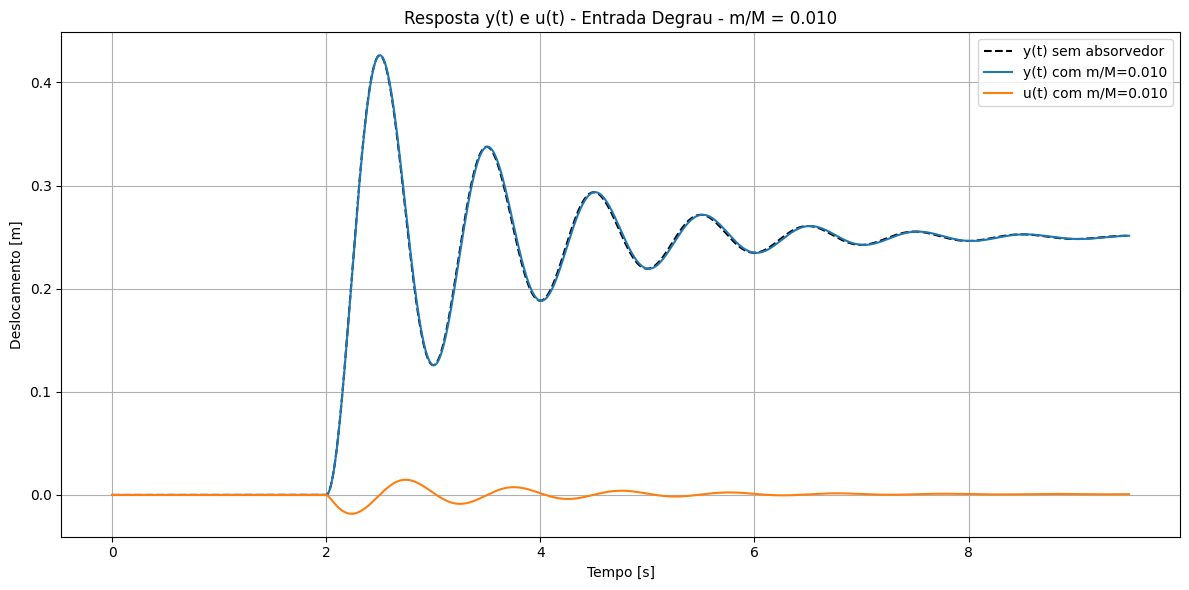

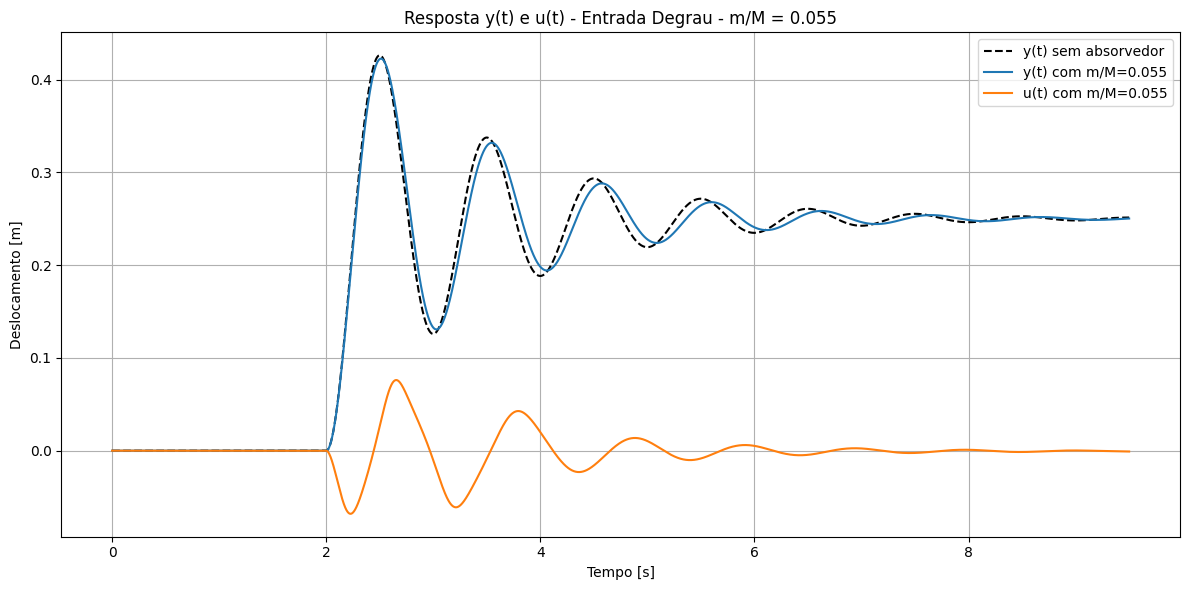

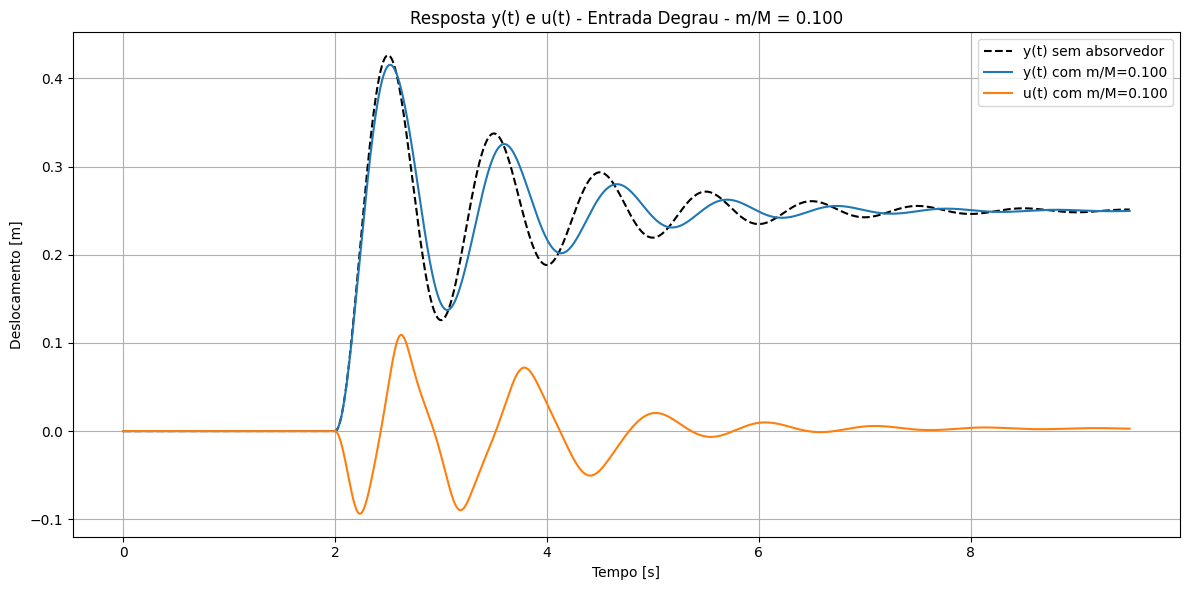

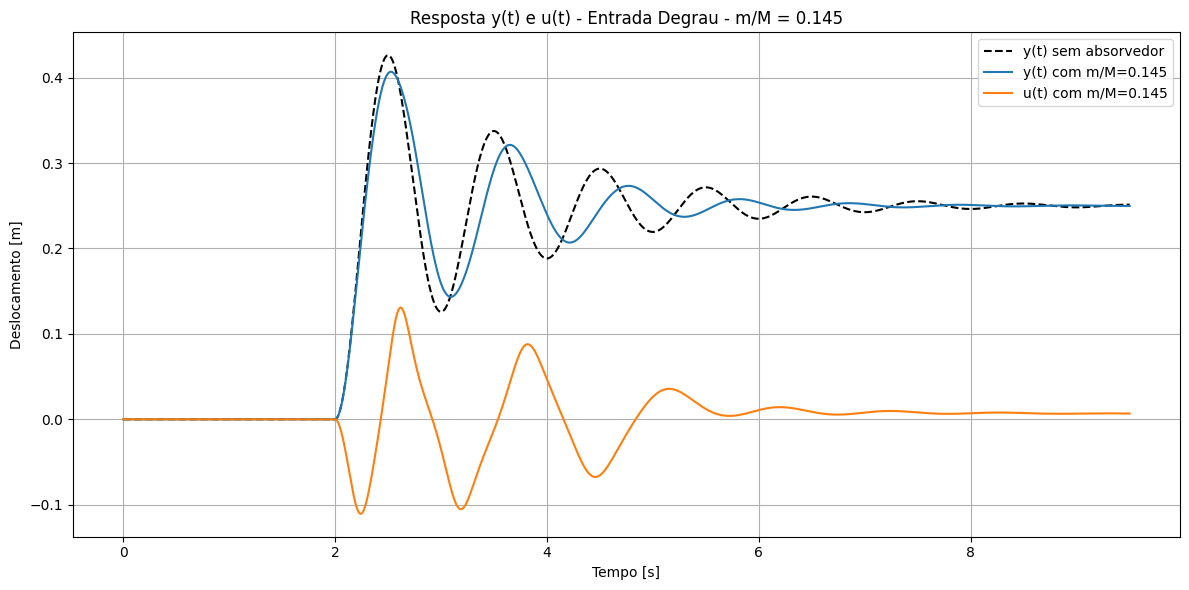

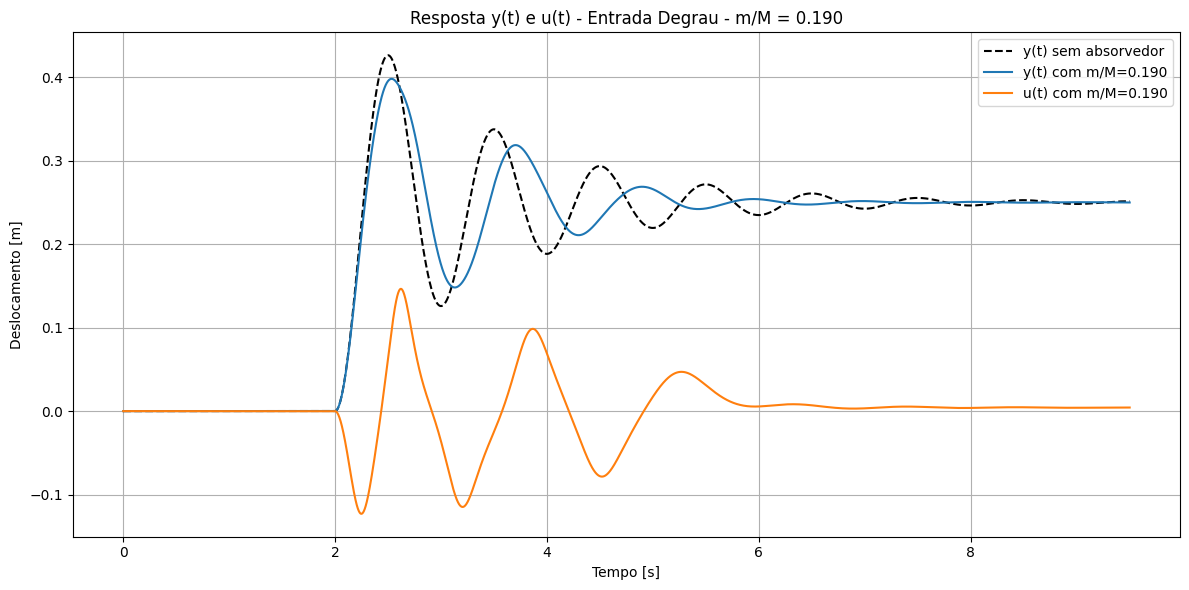

In [ ]:
# --- Parâmetros do sistema ---
M = 500       # kg
Ky = 20000    # N/m
Cy = 700      # Ns/m
k = 10000     # N/m
c = 350       # Ns/m
L = 0.1       # m

# Tempo de simulação e passo
t_final = 9.5
h = 0.001
t = np.arange(0, t_final + h, h)

# Entrada z(t): degrau
def z1(t):
    return 0 if t < 2 else 0.25

def dz1(t):
    return 0  # degrau => derivada é zero exceto em t=2 (descontínuo)

# Sistema de EDOs com mola cúbica (Taylor 3ª ordem)
def system(M, m):
    def f(t, Y):
        y, vy, u, vu = Y
        zt = z1(t)
        dzt = dz1(t)
        dy = vy
        du = vu
        dvy = (-Ky * (y - zt) - Cy * vy + (k * u**3) / (2 * L**2) + c * vu) / M
        dvu = (-m * dvy - (k * u**3) / (2 * L**2) - c * vu) / m
        return np.array([dy, dvy, du, dvu])
    return f

# Sistema sem absorvedor (m = 0)
def system_sem_absorvedor():
    def f(t, Y):
        y, vy = Y
        zt = z1(t)
        dzt = dz1(t)
        dy = vy
        dvy = (-Ky * (y - zt) - Cy * (vy-dzt)) / M
        return np.array([dy, dvy])
    return f


# Razões m/M para testar
ratios = np.arange(0.01, 0.20, 0.045)
resultados = {}

# Simulação sem absorvedor
Y0_no_absorber = [0, 0]
no_absorber = rk4(system_sem_absorvedor(), Y0_no_absorber, t)

# Simulações com absorvedor
for r in ratios:
    m = r * M
    f = system(M, m)
    Y0 = [0, 0, 0, 0]  # [y, vy, u, vu]
    resultados[r] = rk4(f, Y0, t)

# Gráficos por valor de m/M
for r in ratios:
    plt.figure(figsize=(12, 6))
    plt.plot(t, no_absorber[:, 0], label='y(t) sem absorvedor', linestyle='--', color='black')
    plt.plot(t, resultados[r][:, 0], label=f'y(t) com m/M={r:.3f}', color='tab:blue')
    plt.plot(t, resultados[r][:, 2], label=f'u(t) com m/M={r:.3f}', color='tab:orange')
    plt.title(f'Resposta y(t) e u(t) - Entrada Degrau - m/M = {r:.3f}')
    plt.xlabel('Tempo [s]')
    plt.ylabel('Deslocamento [m]')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

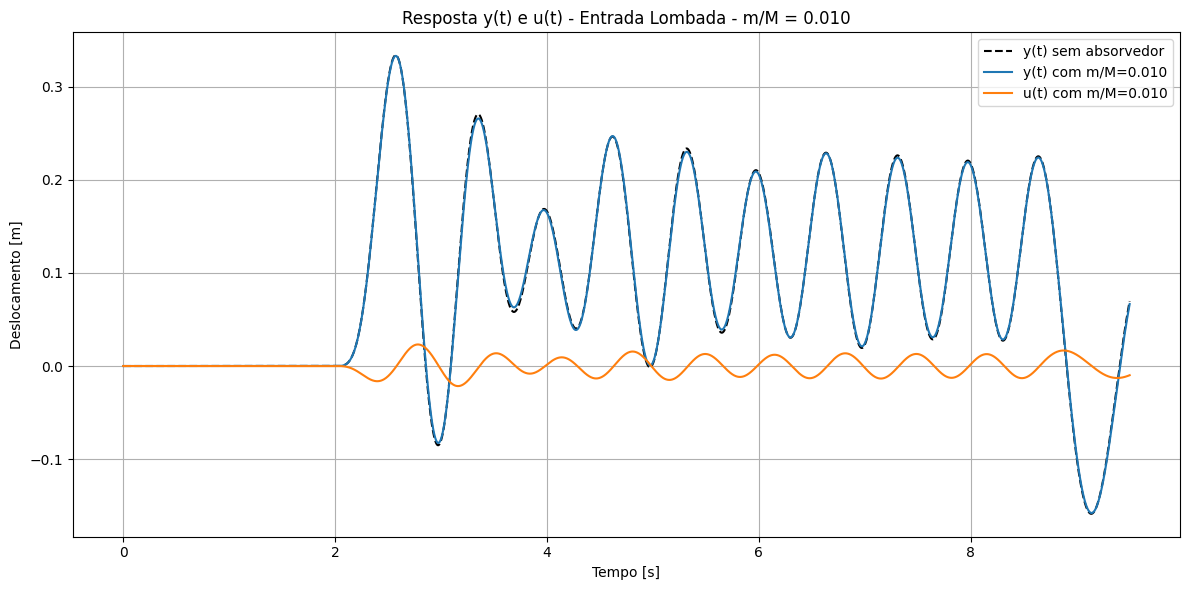

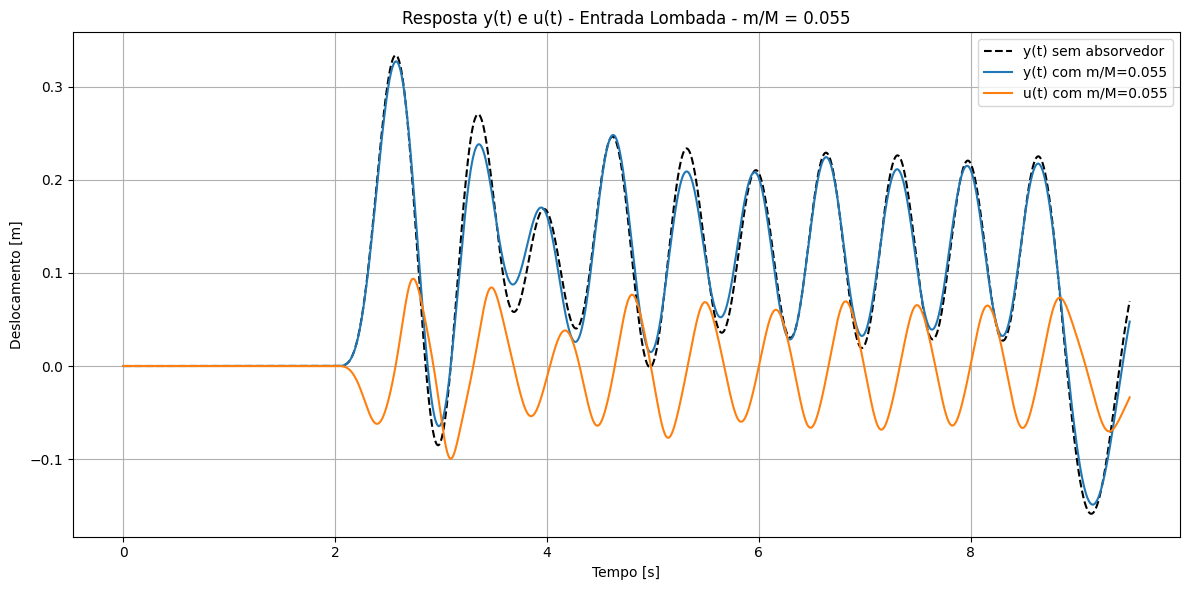

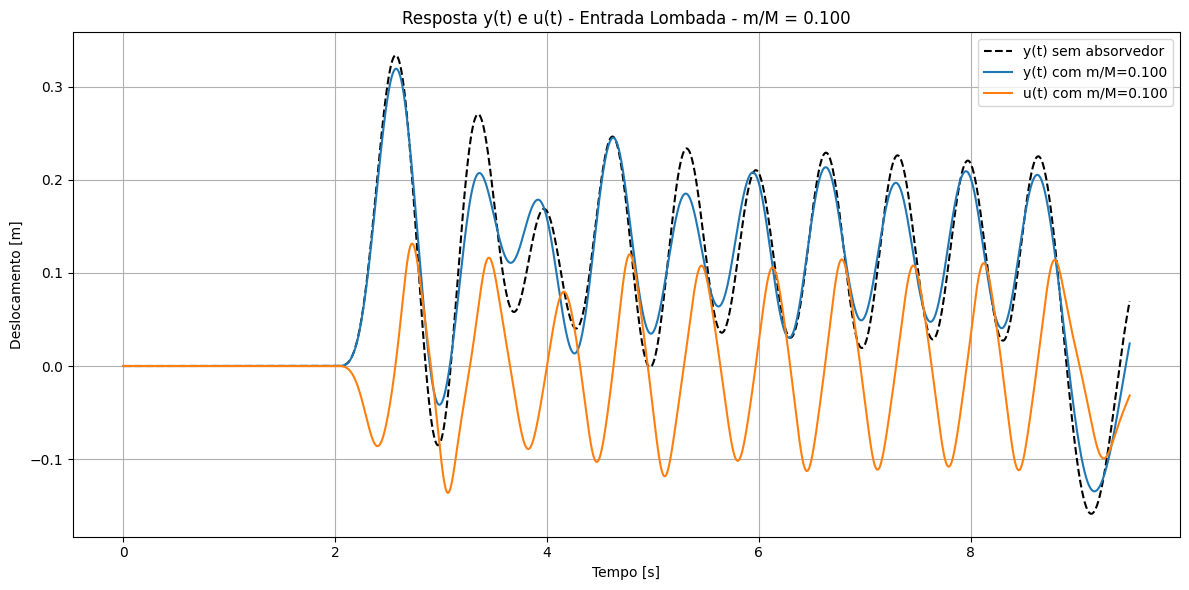

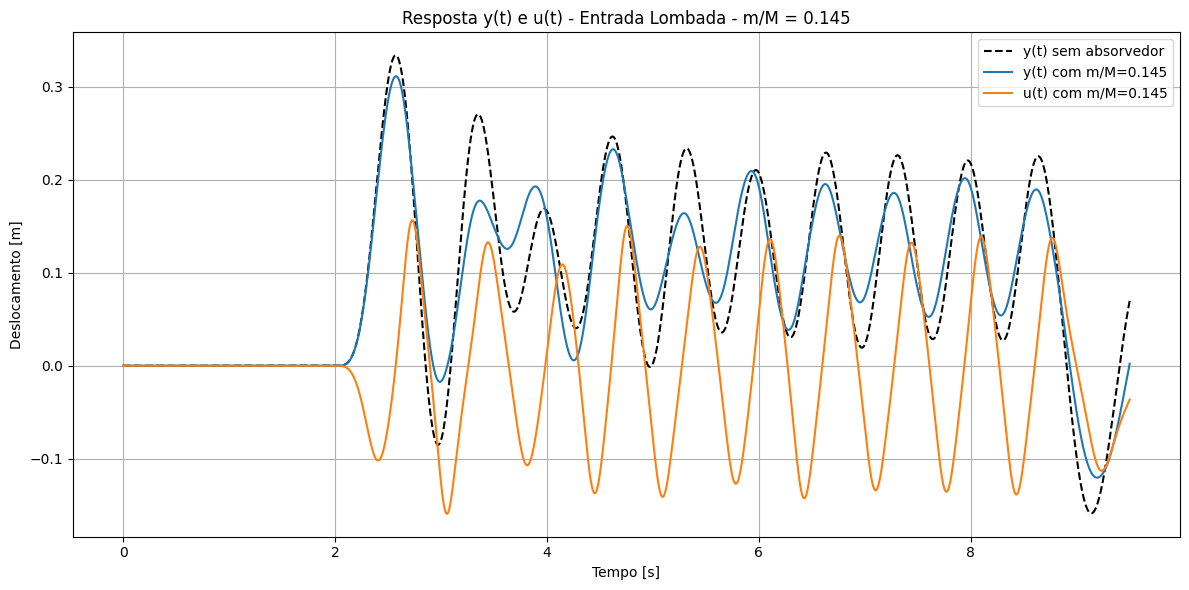

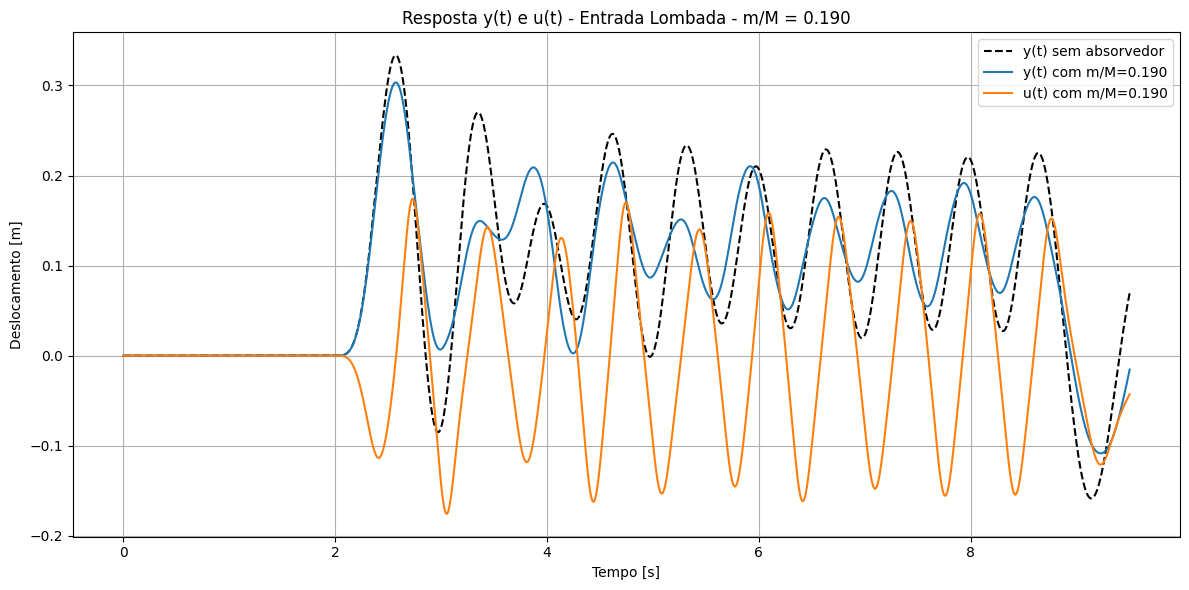

In [ ]:
# --- Tempo de simulação e passo ---
t_final = 9.5
h = 0.001
t = np.arange(0, t_final + h, h)

# --- Entrada z(t): lombada periódica tipo cosseno ---
def z2(t, V=3):  # V = velocidade do veículo [m/s]
    T = 2 / V
    n = math.floor(2 / T)
    n1 = math.floor(2 / T) + 10
    t0 = n * T
    if t0 <= t < n1 * T:
        return 0.125 * (1 - np.cos(2 * np.pi * (t - t0) / T))
    return 0

# --- Sistema de EDOs com absorvedor (não linear cúbico) ---
def system_lombada(M, m):
    def f(t, Y):
        y, vy, u, vu = Y
        zt = z2(t)
        dy = vy
        du = vu
        dvy = (-Ky * (y - zt) - Cy * vy + (k * u**3) / (2 * L**2) + c * vu) / M
        dvu = (-m * dvy - (k * u**3) / (2 * L**2) - c * vu) / m
        return np.array([dy, dvy, du, dvu])
    return f

# --- Sistema de EDOs sem absorvedor ---
def system_lombada_sem_absorvedor():
    def f(t, Y):
        y, vy = Y
        zt = z2(t)
        dy = vy
        dvy = (-Ky * (y - zt) - Cy * vy) / M
        return np.array([dy, dvy])
    return f

# --- Simulações ---
ratios = np.arange(0.01, 0.20, 0.045)  # Razões m/M
Y0_no_absorber = [0, 0]
no_absorber_lombada = rk4(system_lombada_sem_absorvedor(), Y0_no_absorber, t)

resultados_lombada = {}
for r in ratios:
    m = r * M
    f = system_lombada(M, m)
    Y0 = [0, 0, 0, 0]  # [y, vy, u, vu]
    resultados_lombada[r] = rk4(f, Y0, t)

# --- Plots combinados de y(t) e u(t) ---
for r in ratios:
    plt.figure(figsize=(12, 6))
    plt.plot(t, no_absorber_lombada[:, 0], label='y(t) sem absorvedor', linestyle='--', color='black')
    plt.plot(t, resultados_lombada[r][:, 0], label=f'y(t) com m/M={r:.3f}', color='tab:blue')
    plt.plot(t, resultados_lombada[r][:, 2], label=f'u(t) com m/M={r:.3f}', color='tab:orange')
    plt.title(f'Resposta y(t) e u(t) - Entrada Lombada - m/M = {r:.3f}')
    plt.xlabel('Tempo [s]')
    plt.ylabel('Deslocamento [m]')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()


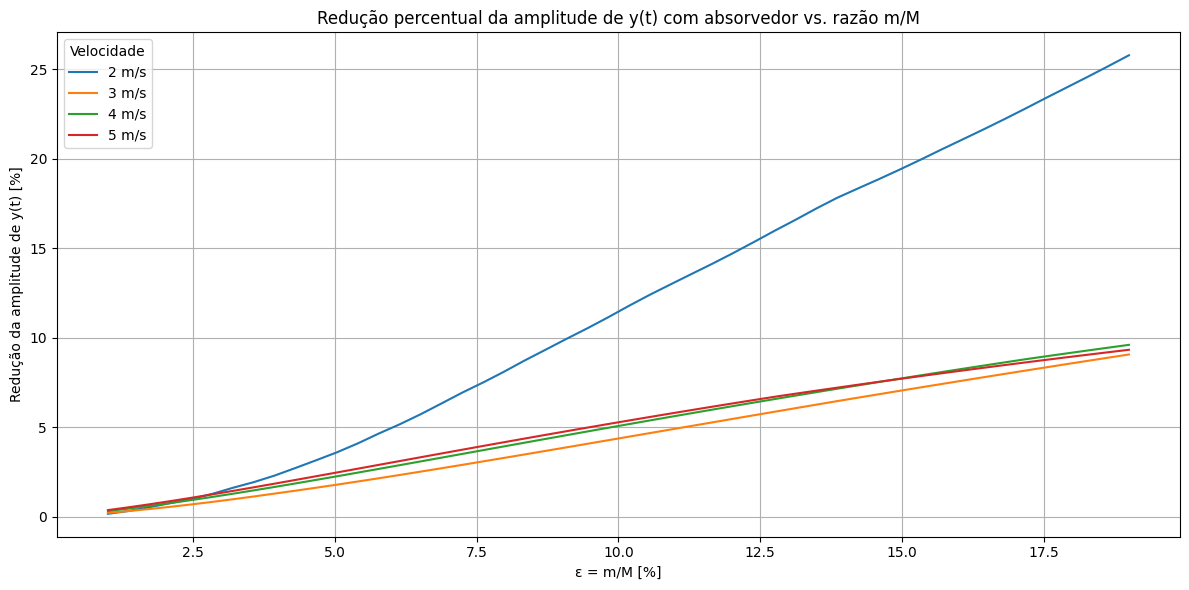

In [ ]:
# --- Configurações de simulação ---
t_final = 10
h = 0.01
t = np.arange(0, t_final + h, h)
epsilons = np.linspace(0.01, 0.19, 50)  # 50 valores de m/M
velocidades = [2, 3, 4, 5]  # m/s

# --- Sistema com absorvedor (mola cúbica) ---
def system_lombada_varV(M, m, V):
    def f(t, Y):
        y, vy, u, vu = Y
        zt = z2(t, V)
        dy = vy
        du = vu
        dvy = (-Ky * (y - zt) - Cy * vy + (k * u**3) / (2 * L**2) + c * vu) / M
        dvu = (-m * dvy - (k * u**3) / (2 * L**2) - c * vu) / m
        return np.array([dy, dvy, du, dvu])
    return f

# --- Sistema sem absorvedor ---
def system_lombada_sem_absorvedor_V(V):
    def f(t, Y):
        y, vy = Y
        zt = z2(t, V)
        dy = vy
        dvy = (-Ky * (y - zt) - Cy * vy) / M
        return np.array([dy, dvy])
    return f

# --- Cálculo das reduções ---
reducoes = {V: [] for V in velocidades}
picos_sem_absorvedor = {}

for V in velocidades:
    # Resposta sem absorvedor
    Y0_base = [0, 0]
    resposta_base = rk4(system_lombada_sem_absorvedor_V(V), Y0_base, t)
    pico_base = np.max(np.abs(resposta_base[:, 0]))
    picos_sem_absorvedor[V] = pico_base

    # Com absorvedor para cada ε
    for eps in epsilons:
        m = eps * M
        Y0 = [0, 0, 0, 0]  # [y, vy, u, vu]
        resposta = rk4(system_lombada_varV(M, m, V), Y0, t)
        pico = np.max(np.abs(resposta[:, 0]))
        reducao = 100 * (1 - pico / pico_base)
        reducoes[V].append(reducao)

# --- Plotagem final ---
plt.figure(figsize=(12, 6))
for V in velocidades:
    plt.plot(epsilons * 100, reducoes[V], label=f'{V} m/s')
plt.title('Redução percentual da amplitude de y(t) com absorvedor vs. razão m/M')
plt.xlabel('ε = m/M [%]')
plt.ylabel('Redução da amplitude de y(t) [%]')
plt.grid()
plt.legend(title='Velocidade')
plt.tight_layout()
plt.show()


<ipython-input-6-63494eefd767>:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Fy = np.trapz((p_atm-p_telhado) * np.sin(theta) * (R), theta)


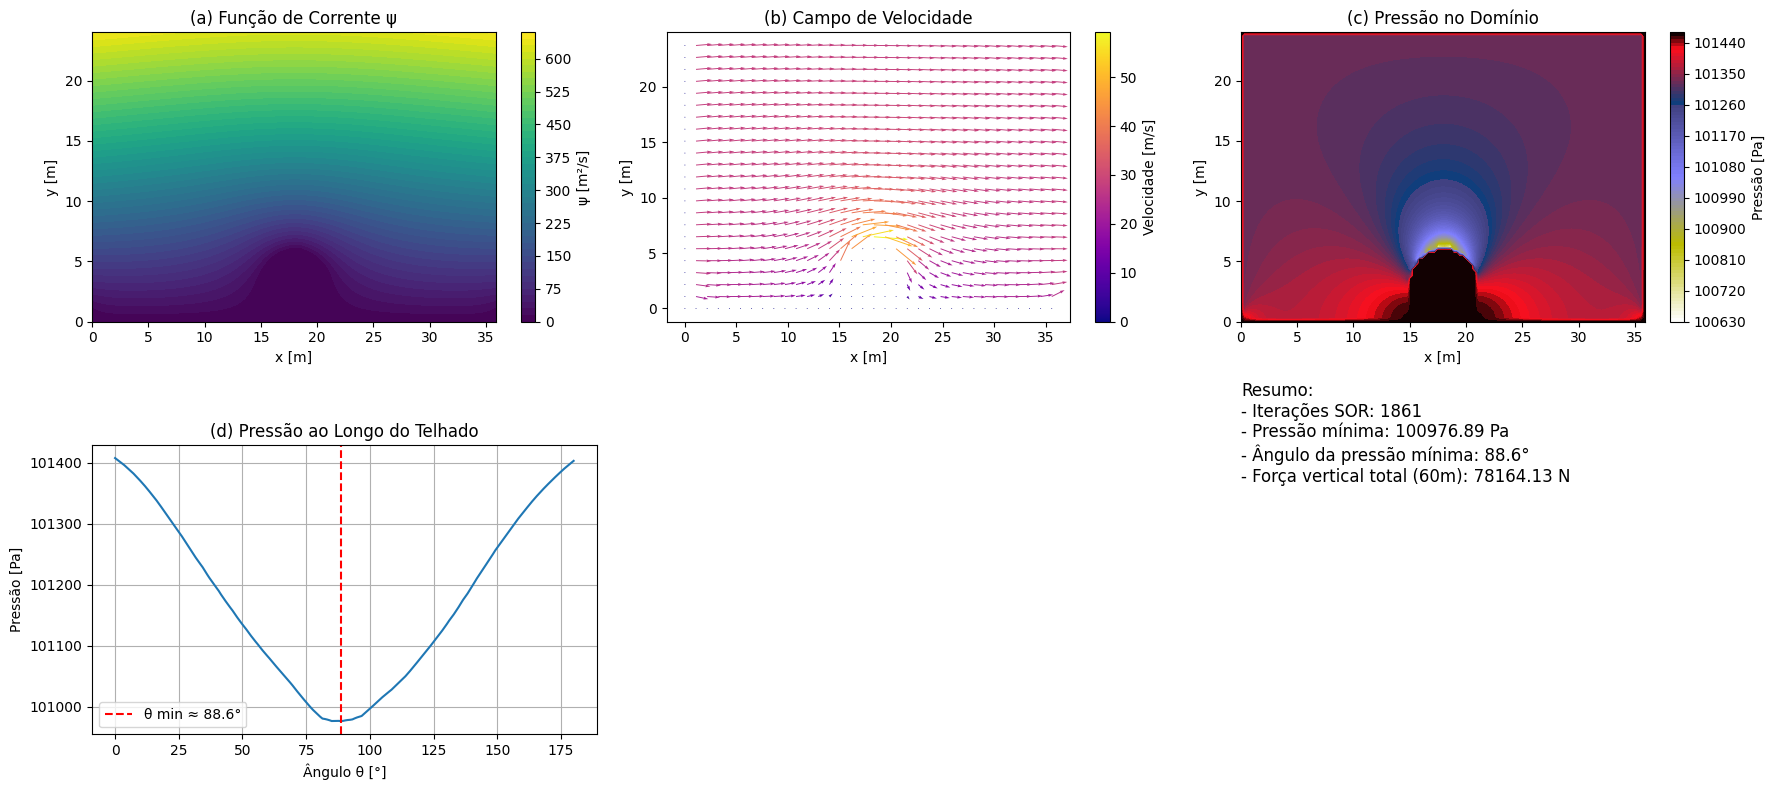

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# =================================================
# 1. PARÂMETROS DO PROBLEMA
# =================================================
H = 24.0
L = 6.0
d = 15.0
h = 3.0
Vref = 100 / 3.6  # 27.78 m/s
rho = 1.25
p_atm = 101325
gamma = 1.4
comprimento = 60  # comprimento do prédio (m)

# =================================================
# 2. MALHA
# =================================================
Ny = 90
dy = H / (Ny - 1)
dx = dy
Nx = int((2*d + L)/dx) + 1

x = np.linspace(0, (Nx - 1)*dx, Nx)
y = np.linspace(0, (Ny - 1)*dy, Ny)
X, Y = np.meshgrid(x, y)

# =================================================
# 3. GEOMETRIA (TELHADO + PAREDE)
# =================================================
xc, yc, R = d + L/2, h, L/2
telhado_mask = ((X-xc)**2 + (Y-yc)**2 <= R**2) & (Y >= yc)
parede_mask = (X >= xc-R) & (X <= xc+R) & (Y <= yc)
obstacle_mask = telhado_mask | parede_mask

# =================================================
# 4. CONDIÇÕES DE CONTORNO: Perfil parabólico
# =================================================
u_inlet = np.where(y <= 0.05*H, Vref * (y/(0.05*H))**2, Vref)

# =================================================
# 5. SOR para ψ
# =================================================
def apply_BC(psi):
    psi[0, :] = 0.0
    psi[obstacle_mask] = 0.0
    psi[1:, 0] = psi[0:-1, 0] + u_inlet[1:] * dy
    psi[1:, -1] = psi[0:-1, -1] + u_inlet[1:] * dy
    psi[-1, :] = psi[-2, :] + Vref * dy

def solve_sor(psi, w=1.85, tol=1e-4, max_iter=5000):
    err, it = 1.0, 0
    while err > tol and it < max_iter:
        err = 0.0
        for i in range(1, Ny-1):
            for j in range(1, Nx-1):
                if not obstacle_mask[i,j]:
                    old = psi[i,j]
                    psi[i,j] = (1-w)*old + w*0.25*(psi[i+1,j] + psi[i-1,j] + psi[i,j+1] + psi[i,j-1])
                    err = max(err, abs(psi[i,j]-old))
        apply_BC(psi)
        it += 1
    return psi, it

psi = np.zeros_like(X)
apply_BC(psi)
psi, n_iter = solve_sor(psi)

# =================================================
# 6. VELOCIDADE E PRESSÃO
# =================================================
u = np.zeros_like(X)
v = np.zeros_like(X)
u[1:-1, 1:-1] = (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2*dy)
v[1:-1, 1:-1] = -(psi[1:-1, 2:] - psi[1:-1, :-2]) / (2*dx)
u[obstacle_mask] = 0.0
v[obstacle_mask] = 0.0

Vmag = np.sqrt(u**2 + v**2)
p = p_atm + rho * (gamma - 1) / gamma * ((Vref**2)/2 - (Vmag**2)/2)

# =================================================
# 7. INTERPOLAÇÃO DA PRESSÃO SOBRE O TELHADO
# =================================================
theta = np.linspace(0, np.pi, 200)
x_telhado = xc + (R+1)*np.cos(theta)
y_telhado = yc + (R+1)*np.sin(theta)

# Interpolador 2D
interp_p = RegularGridInterpolator((y, x), p)
p_telhado = interp_p(np.array([y_telhado, x_telhado]).T)

# Força vertical: integrar p*sin(θ) ao longo do arco
Fy = np.trapz((p_atm-p_telhado) * np.sin(theta) * (R), theta)
Fy_total = Fy * comprimento

# Menor pressão e posição
p_min = np.min(p_telhado)
theta_min = theta[np.argmin(p_telhado)]

# =================================================
# 8. VISUALIZAÇÃO
# =================================================
plt.figure(figsize=(18, 8))

# (a) ψ
plt.subplot(2, 3, 1)
plt.contourf(X, Y, psi, 50, cmap='viridis')
plt.colorbar(label='ψ [m²/s]')
plt.title('(a) Função de Corrente ψ')
plt.xlabel('x [m]'); plt.ylabel('y [m]')

# (b) Campo de velocidade com cor pela magnitude
plt.subplot(2, 3, 2)
skip = (slice(None, None, 4), slice(None, None, 4))
plt.quiver(X[skip], Y[skip], u[skip], v[skip], Vmag[skip], cmap='plasma', scale=700)
plt.colorbar(label='Velocidade [m/s]')
plt.title('(b) Campo de Velocidade')
plt.xlabel('x [m]'); plt.ylabel('y [m]')

# (c) Pressão no domínio
plt.subplot(2, 3, 3)
plt.contourf(X, Y, p, 100, cmap='gist_stern_r')
plt.colorbar(label='Pressão [Pa]')
plt.title('(c) Pressão no Domínio')
plt.xlabel('x [m]'); plt.ylabel('y [m]')

# (d) Pressão ao longo do telhado
plt.subplot(2, 3, 4)
plt.plot(np.degrees(theta), p_telhado)
plt.title('(d) Pressão ao Longo do Telhado')
plt.xlabel('Ângulo θ [°]')
plt.ylabel('Pressão [Pa]')
plt.grid(True)
plt.axvline(np.degrees(theta_min), linestyle='--', color='r', label=f'θ min ≈ {np.degrees(theta_min):.1f}°')
plt.legend()

# (e) Texto resumido
plt.subplot(2, 3, 6)
plt.axis('off')
text = f"""Resumo:
- Iterações SOR: {n_iter}
- Pressão mínima: {p_min:.2f} Pa
- Ângulo da pressão mínima: {np.degrees(theta_min):.1f}°
- Força vertical total (60m): {Fy_total:.2f} N
"""
plt.text(0, 0.8, text, fontsize=12)

plt.tight_layout()
plt.show()


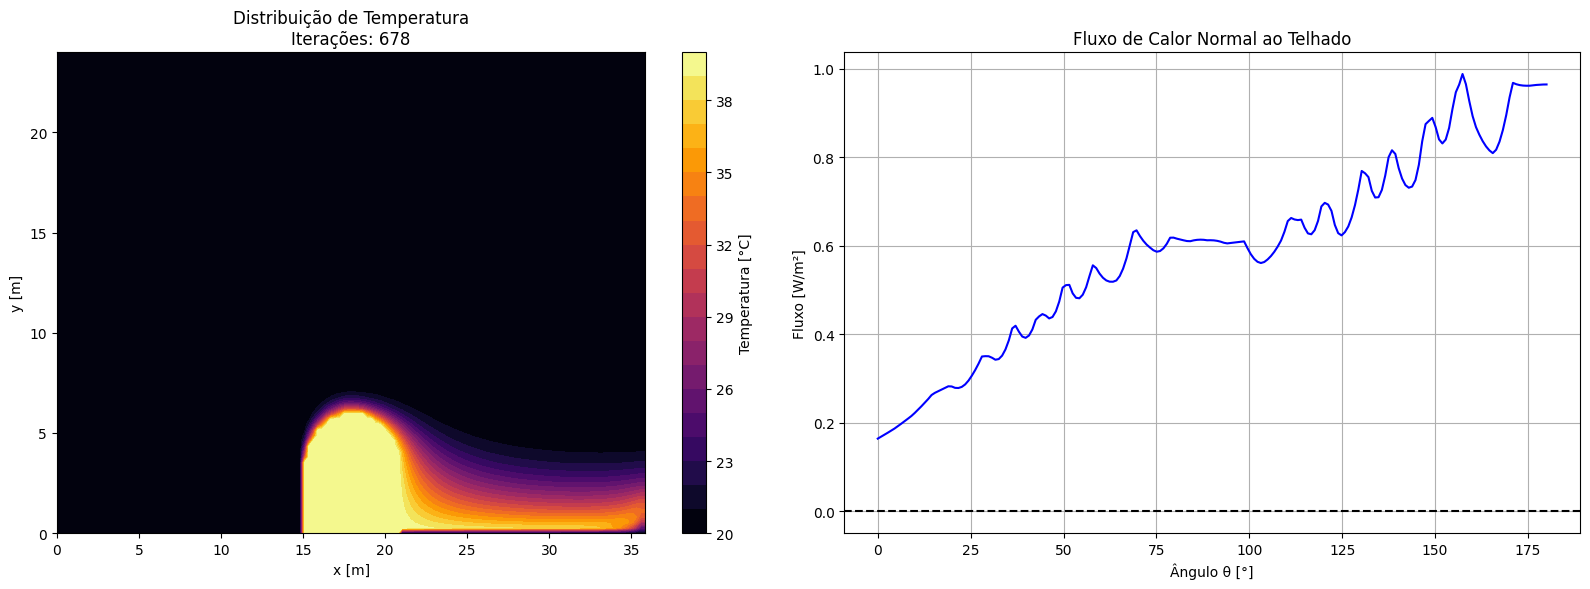

Taxa total de calor retirada do prédio: 349.37 W


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.integrate import simpson

# ------------------------------
#  PARÂMETROS GERAIS
# ------------------------------
H = 24.0
L = 6.0
h = 3.0
d = 15.0
R = L / 2
xc, yc = d + R, h
comprimento = 60.0

Vref = 100 / 3.6  # 27.78 m/s
rho = 1.25
cp = 1002
k = 0.026
alpha = k / (rho * cp)

T_dentro = 40
T_fora = 20

# ------------------------------
# 1. EQUAÇÃO DA ENERGIA COM PASSO DE TEMPO EXPLÍCITO
# ------------------------------
T = np.full_like(X, T_fora, dtype=np.float64)
T[obstacle_mask] = T_dentro

dt_diff = 0.25 * min(dx, dy)**2 / alpha
umax = np.max(np.abs(u))
vmax = np.max(np.abs(v))
dt_conv = min(dx / umax, dy / vmax)
dt = 0.5 * min(dt_diff, dt_conv)
tol = 0.01
max_iter = 10000

for it in range(max_iter):
    T_old = T.copy()
    for i in range(1, Ny - 1):
        for j in range(1, Nx - 1):
            if obstacle_mask[i, j]:
                continue

            d2Tdx2 = (T_old[i, j+1] - 2*T_old[i, j] + T_old[i, j-1]) / dx**2
            d2Tdy2 = (T_old[i+1, j] - 2*T_old[i, j] + T_old[i-1, j]) / dy**2
            diffusion = alpha * (d2Tdx2 + d2Tdy2)

            if u[i, j] > 0:
                dTdx = (T_old[i, j] - T_old[i, j-1]) / dx
            else:
                dTdx = (T_old[i, j+1] - T_old[i, j]) / dx

            if v[i, j] > 0:
                dTdy = (T_old[i, j] - T_old[i-1, j]) / dy
            else:
                dTdy = (T_old[i+1, j] - T_old[i, j]) / dy

            convection = u[i, j] * dTdx + v[i, j] * dTdy
            T[i, j] += dt * (diffusion - convection)

    T[:, 0] = T[:, 1]
    T[:, -1] = T[:, -2]
    T[-1, :] = T[-2, :]

    if np.max(np.abs(T - T_old)) < tol:
        break

n_iter_T = it + 1

# ------------------------------
# 2. FLUXO DE CALOR PELO TELHADO
# ------------------------------
dTdy = np.zeros_like(T)
dTdx = np.zeros_like(T)
dTdy[1:-1, :] = (T[2:, :] - T[:-2, :]) / (2*dy)
dTdx[:, 1:-1] = (T[:, 2:] - T[:, :-2]) / (2*dx)

interp_dTdx = RegularGridInterpolator((y, x), dTdx, bounds_error=False, fill_value=0)
interp_dTdy = RegularGridInterpolator((y, x), dTdy, bounds_error=False, fill_value=0)

theta = np.linspace(0, np.pi, 200)
R_ext = R + 0.5 * dx
x_telhado_ext = xc + R_ext * np.cos(theta)
y_telhado_ext = yc + R_ext * np.sin(theta)

dTdx_ext = interp_dTdx(np.column_stack((y_telhado_ext, x_telhado_ext)))
dTdy_ext = interp_dTdy(np.column_stack((y_telhado_ext, x_telhado_ext)))
q_normal_ext = -k * (dTdx_ext * np.cos(theta) + dTdy_ext * np.sin(theta))

Q_total = simpson(q_normal_ext * R_ext, theta) * comprimento

# ------------------------------
# 3. PLOTAGEM DOS RESULTADOS
# ------------------------------
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.contourf(X, Y, T, levels=20, cmap='inferno')
plt.colorbar(label='Temperatura [°C]')
plt.title(f'Distribuição de Temperatura\nIterações: {n_iter_T}')
plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.subplot(1, 2, 2)
plt.plot(np.degrees(theta), q_normal_ext, 'b-')
plt.axhline(0, color='k', linestyle='--')
plt.title('Fluxo de Calor Normal ao Telhado')
plt.xlabel('Ângulo θ [°]')
plt.ylabel('Fluxo [W/m²]')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Taxa total de calor retirada do prédio: {Q_total:.2f} W")
